In [1]:
import pcdl
import numpy as np
from numpy.linalg import norm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:531: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to preserve the old behavior
  left = partial(_left_join_spatialelement_table)
/home/vincent/.local/share/mamba/envs/certainty/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:532: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in enum.member() if you want to p

In [2]:
mcdsts = pcdl.TimeSeries('output/', verbose=False)

In [3]:
data = mcdsts.get_cell_df()

In [4]:
data = data.loc[:, ['ID', 'time', 'position_x', 'position_y', 'position_z', 'cell_type']]

In [5]:
data.to_csv("physicell_data.csv")

In [6]:
data = pd.read_csv("physicell_data.csv")

In [7]:
ids = list(set(data.loc[:, 'ID']))
times = sorted(list(set(data.loc[:, 'time'])))
time_step = times[1] - times[0]
cell_types = list(set(data.loc[:, 'cell_type']))
max_time = np.max(times)

In [8]:
print(f"Simulation loaded: {len(ids)} cells, {len(times)} timepoints")

Simulation loaded: 700 cells, 501 timepoints


In [9]:
from track_metrics import enrich_data_with_metrics
from plotting import plot_tracks
from fitting import compute_motility_correction_factor

In [10]:
data = enrich_data_with_metrics(data)

Calculating Displacement X...
Calculating Displacement Y...
Calculating Displacement Z...
Added variable 'Turning Angle (rad)' and 'Turning Angle (deg)' to data
Added variable 'Displacement^2' to data
Added variable 'Track Turning Angle Sum (rad)' to data
Added variable 'Track Turning Angle Sum (deg)' to data
Added variable 'Spatial Coverage' to data


In [11]:
data.head(10)

,index,ID,time,position_x,position_y,position_z,cell_type,Time_rel,Displacement X,Displacement Y,Displacement Z,Displacement_vector_length,Turning Angle (rad),Turning Angle (deg),Displacement^2,Track Turning Angle Sum (rad),Track Turning Angle Sum (deg),Spatial Coverage
0,0,0,0.0,-379.780917,-486.428302,0.0,Plasma,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,63.276595,3625.481835,0.000009
1,700,0,2.0,-379.779675,-486.428356,0.0,Plasma,2.0,0.001242,-0.000054,0.0,0.001244,NaN,NaN,0.000002,63.276595,3625.481835,0.000009
2,1400,0,4.0,-379.778455,-486.428409,0.0,Plasma,4.0,0.001219,-0.000053,0.0,0.001221,0.000000e+00,0.000000e+00,0.000001,63.276595,3625.481835,0.000009
3,2100,0,6.0,-379.777228,-486.428462,0.0,Plasma,6.0,0.001227,-0.000053,0.0,0.001228,1.490116e-08,8.537736e-07,0.000002,63.276595,3625.481835,0.000009
4,2800,0,8.0,-379.775994,-486.428516,0.0,Plasma,8.0,0.001234,-0.000054,0.0,0.001235,1.490116e-08,8.537736e-07,0.000002,63.276595,3625.481835,0.000009
5,3500,0,10.0,-379.876654,-486.402942,0.0,Plasma,10.0,-0.100660,0.025574,0.0,0.103858,2.936162e+00,1.682297e+02,0.010786,63.276595,3625.481835,0.000009
6,4200,0,12.0,-380.069885,-486.354166,0.0,Plasma,12.0,-0.193230,0.048776,0.0,0.199291,1.537399e-03,8.808645e-02,0.039717,63.276595,3625.481835,0.000009
7,4900,0,14.0,-380.263490,-486.305374,0.0,Plasma,14.0,-0.193605,0.048792,0.0,0.199659,3.804686e-04,2.179925e-02,0.039864,63.276595,3625.481835,0.000009
8,5600,0,16.0,-380.457378,-486.256568,0.0,Plasma,16.0,-0.193888,0.048806,0.0,0.199936,2.805984e-04,1.607710e-02,0.039975,63.276595,3625.481835,0.000009
9,6300,0,18.0,-380.651331,-486.207760,0.0,Plasma,18.0,-0.193953,0.048809,0.0,0.200000,6.441192e-05,3.690531e-03,0.040000,63.276595,3625.481835,0.000009


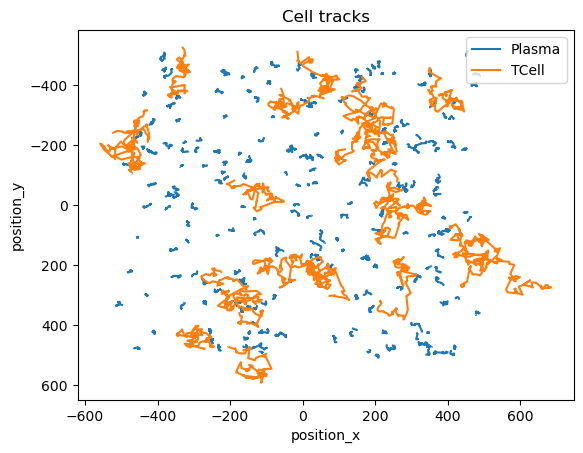

In [12]:
plot_tracks(data[(data.ID < 200) | (data.ID > 675)], position_vars=['position_x', 'position_y'], 
            time_var='time', trackid_var="ID", title="Cell tracks", 
            hue_var='cell_type')

Processing cell type: TCell


  0%|          | 0/501 [00:00<?, ?it/s]

Fitted parameters: [5.06357109]
Covariance of parameters: [[0.00098362]]
Estimated persistence time in time frames: τ_p = 5.063571092640695
Estimated persistence time τ_p = 5.063571092640695 time frames, or 10.12714218528139 minutes


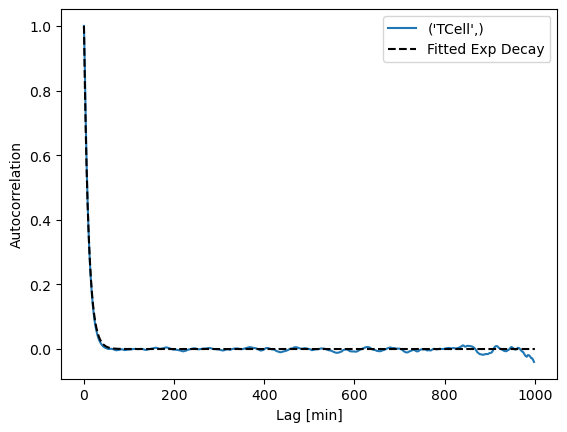

✓ Fitted D = 4.418729e-01
  Covariance: 4.264513e-09
✓ Fitted v = 2.954066e-01
  Covariance: 4.764915e-10
Estimated D from D fit: 0.44187285365660006
Estimated D from v fit: 0.4418728536870026


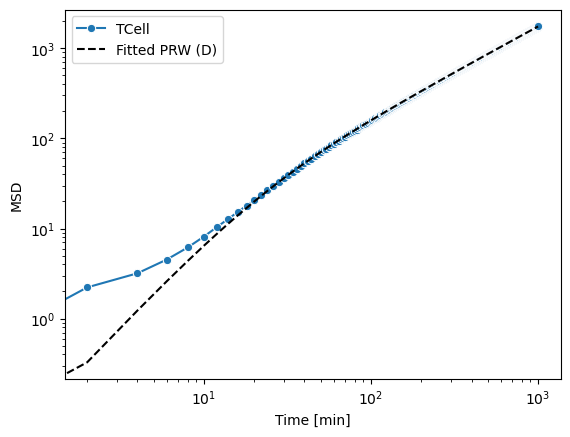

Processing cell type: Plasma


  0%|          | 0/501 [00:00<?, ?it/s]

Fitted parameters: [5.60348276]
Covariance of parameters: [[0.03437611]]
Estimated persistence time in time frames: τ_p = 5.603482755136882
Estimated persistence time τ_p = 5.603482755136882 time frames, or 11.206965510273765 minutes


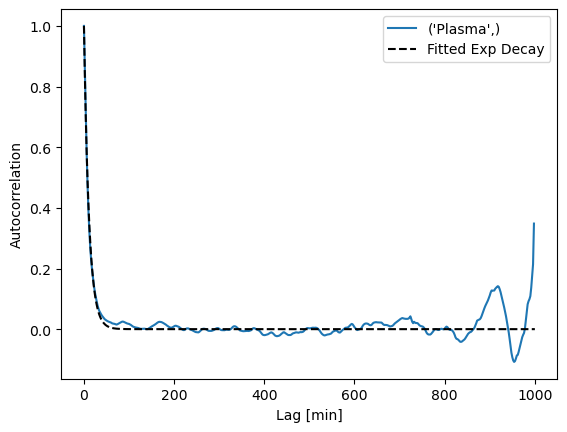

✓ Fitted D = 7.781019e-03
  Covariance: 3.963888e-09
✓ Fitted v = 3.726398e-02
  Covariance: 2.272829e-08
Estimated D from D fit: 0.007781018788006297
Estimated D from v fit: 0.00778101879008578


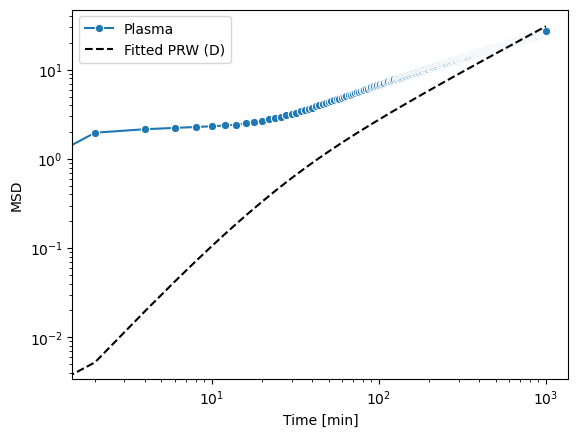

In [13]:
for cell_type in cell_types:
    print(f"Processing cell type: {cell_type}")
    ## Example data set
    data_sample = data.loc[(data['cell_type'] == cell_type)]
    data_sample


    objective_speed = 1.0
    objective_persistence_time = 10.0

    correction_speed, correction_persistence_time = compute_motility_correction_factor(data_sample, time_step, max_time, objective_speed, objective_persistence_time, verbose=True)